# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maryam-Shile/flyrank_ml_internship/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes

Rule: flag informational keyword-article pages with ≥100 impressions in the last 90 days whose performance_score falls in the bottom 20 rows and whose trend_direction is 'down'.

Reason codes: [low_ctr_high_impressions], [declining_search_visibility], [stale_content], [thin_content] — assigned per page by reviewing where it falls on each feature's scatter plot relative to the rest of the group, not by the selection criteria itself.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

In [12]:
url = 'https://raw.githubusercontent.com/Maryam-Shile/flyrank_ml_internship/refs/heads/main/data/raw/content_refresh_anonymized.csv'
df = pd.read_csv(url)
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [13]:
df['impressions_90d'].describe()

,impressions_90d
count,30000.000000
mean,5200.366300
std,16838.019547
min,1.000000
25%,81.000000
50%,731.000000
75%,3615.250000
max,517715.000000


In [14]:
df[['search_volume', 'competition']].describe()

,search_volume,competition
count,27532.000000,27532.000000
mean,158.882391,0.146954
std,1518.270825,0.285241
min,0.000000,0.000000
25%,0.000000,0.000000
50%,10.000000,0.000000
75%,20.000000,0.130000
max,74000.000000,1.000000


In [26]:
df['search_volume'] = df['search_volume'].replace(0, np.nan)
df['competition'] = df['competition'].replace(0, np.nan)

In [28]:
df_new = df[df['impressions_90d'] >= 100].copy()
df_new.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,NaN,NaN,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,NaN,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,NaN,NaN,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [29]:
df_new['search_volume_log'] = np.log10(df['search_volume'] + 1)

#density or penetration score
opportunity_index = 1 - df_new['competition'] * df_new['search_volume_log']
df_new['opportunity_score'] = df_new['search_volume_log'] * opportunity_index
df_new['opportunity_score'].describe()

,opportunity_score
count,8735.000000
mean,0.603981
std,1.458325
min,-15.559838
25%,0.184639
50%,0.889563
75%,1.304737
max,4.033432


In [17]:
df_new['main_intent_x_content_type'] = df_new['main_intent'] + '_' + df_new['content_type']
info_data = df_new[df_new['main_intent_x_content_type'] == 'informational_keyword article'].copy()
info_data = info_data.drop(columns = ['main_intent_x_content_type'], axis = 1)

to_drop = []

for i in info_data.columns:
  if 'tier' in i:
    to_drop.append(i)
info_data = info_data.drop(columns = to_drop, axis = 1)


performance_columns = ['impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d','ctr', 'avg_position', 'engagement_rate',
       'scroll_rate', 'ai_traffic_pct', 'trend_direction', 'trend_pct']

performance_data = info_data[performance_columns]


for i in performance_data.columns:
  if '30d' in i:
    performance_data = performance_data.drop(columns = [i], axis = 1)


performance_data = performance_data.drop(columns = ['sessions_90d', 'users_90d'], axis = 1)

info_data['avg_position'] = info_data['avg_position'].replace(0, pd.NA)

performance_columns = list(performance_data)
content_data_columns = ['content_id', 'client_id', 'cpc', 'content_type',
                        'main_intent', 'word_count',
                        'char_count', 'provider_used', 'model_used',
                        'content_age_days','days_since_last_update']

environment_columns = ['search_volume', 'competition', 'opportunity_score']

final_columns = content_data_columns + performance_columns + environment_columns

final_data = info_data[final_columns].copy()

#2. **SCORING**

In [18]:

higher = ['impressions_90d', 'clicks_90d', 'pageviews_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'ctr', 'engagement_rate',
          'scroll_rate', 'ai_traffic_pct']
lower = ['avg_position']

for i in higher:
  name = i + '_rank'
  final_data[name] = final_data[i].rank(pct = True)

for j in lower:
  name = j + '_rank'
  final_data[name] = (-final_data[j]).rank(pct = True)

  perfomance_metrics = []
for i in final_data.columns:
  if 'rank' in i:
    perfomance_metrics.append(i)

final_data['performance_score'] = final_data[perfomance_metrics].sum(axis = 1) * 100 / len(perfomance_metrics)
final_data.head()

,content_id,client_id,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,content_age_days,...,ai_sessions_90d_rank,scroll_events_90d_rank,days_with_impressions_rank,days_with_sessions_rank,ctr_rank,engagement_rate_rank,scroll_rate_rank,ai_traffic_pct_rank,avg_position_rank,performance_score
1,content_a1fb4e703a9e,client_4e07408562,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,445,...,0.458852,0.440011,0.744978,0.477344,0.322096,0.316296,0.658740,0.458852,0.328402,49.622905
2,content_9aa793d4d895,client_7f2253d7e2,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,141,...,0.458852,0.735207,0.744978,0.536904,0.400420,0.316296,0.854280,0.458852,0.106898,53.597835
4,content_d99b7a2d90ca,client_3fdba35f04,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,263,...,0.458852,0.981236,0.744978,0.833463,0.480769,0.316296,0.819507,0.458852,0.063921,62.435768
8,content_5e6c160719bc,client_6208ef0f77,0.00,keyword article,informational,3807.0,24228.0,google,gemini-3-flash-preview,90,...,0.458852,0.843779,0.336188,0.893102,0.400420,0.861414,0.560190,0.458852,0.056486,65.055868
9,content_c27558df2b0c,client_19581e27de,0.00,keyword article,informational,NaN,NaN,NaN,NaN,257,...,0.458852,0.168678,0.744978,0.180162,0.537060,0.316296,0.168915,0.458852,0.906960,40.922754


## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

In [19]:
final_sorted = final_data.sort_values(by = 'performance_score', ascending = False)
bottom = final_sorted.tail(20).copy()
bottom

,content_id,client_id,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,content_age_days,...,ai_sessions_90d_rank,scroll_events_90d_rank,days_with_impressions_rank,days_with_sessions_rank,ctr_rank,engagement_rate_rank,scroll_rate_rank,ai_traffic_pct_rank,avg_position_rank,performance_score
3938,content_7e62e609fca2,client_8527a891e2,0.00,keyword article,informational,3582.0,22853.0,google,gemini-3-flash-preview,91,...,0.458852,0.168678,0.046948,0.036554,0.133954,0.316296,0.168915,0.458852,0.001090,17.968606
23321,content_23f366c08715,client_8527a891e2,0.03,keyword article,informational,3460.0,20931.0,NaN,gpt-4o-mini,277,...,0.458852,0.168678,0.061157,0.036554,0.133954,0.316296,0.168915,0.458852,0.032661,17.891946
20746,content_a57d4e24594d,client_2c624232cd,0.00,keyword article,informational,NaN,NaN,NaN,gpt-4o-mini,438,...,0.458852,0.168678,0.038734,0.036554,0.133954,0.316296,0.168915,0.458852,0.056135,17.889551
17470,content_01e6f180a032,client_8527a891e2,0.00,keyword article,informational,1558.0,9759.0,NaN,gpt-4o-mini,273,...,0.458852,0.168678,0.064894,0.036554,0.133954,0.316296,0.168915,0.458852,0.017751,17.889251
10259,content_0d8b669dcf9d,client_2c624232cd,0.00,keyword article,informational,NaN,NaN,NaN,gpt-4o-mini,438,...,0.458852,0.168678,0.054422,0.036554,0.133954,0.316296,0.168915,0.458852,0.005528,17.873680
14622,content_2b996a489e28,client_f74efabef1,0.00,keyword article,informational,2971.0,19809.0,NaN,gemini-2.5-flash,175,...,0.458852,0.168678,0.005022,0.036554,0.133954,0.316296,0.168915,0.458852,0.027756,17.863498
22304,content_f5ee17621665,client_f74efabef1,0.00,keyword article,informational,2544.0,17827.0,google,gemini-3-flash-preview,97,...,0.458852,0.168678,0.022501,0.036554,0.133954,0.316296,0.168915,0.458852,0.046909,17.861702
29596,content_428018a7d0b0,client_9f14025af0,0.00,keyword article,informational,814.0,5749.0,NaN,gpt-4o-mini,306,...,0.458852,0.168678,0.001596,0.036554,0.133954,0.316296,0.168915,0.458852,0.013391,17.817083
5144,content_ff71c103ba32,client_a88a7902cb,0.00,keyword article,informational,2928.0,18904.0,google,gemini-3-flash-preview,126,...,0.458852,0.168678,0.050646,0.036554,0.133954,0.316296,0.168915,0.458852,0.026822,17.807800
27845,content_e4140e1baa5e,client_19581e27de,1.30,keyword article,informational,NaN,NaN,NaN,NaN,480,...,0.458852,0.168678,0.054422,0.036554,0.133954,0.316296,0.168915,0.458852,0.011523,17.783245


In [20]:
bottom['trend_direction'].value_counts()

,count
trend_direction,
down,10
up,3
stable,3
new,3
flat,1


In [21]:
down = final_sorted[final_sorted['trend_direction'] == 'down'].tail(20).copy()

In [30]:
down['avg_position'].describe()

,avg_position
count,20.000000
mean,59.615000
std,11.422198
min,29.500000
25%,51.875000
50%,62.900000
75%,68.075000
max,73.900000


In [22]:
loop = performance_columns + environment_columns
num_cols = list(down[loop].select_dtypes(include=['number']).columns)
cat_cols = list(down[loop].select_dtypes(exclude=['number']).columns)

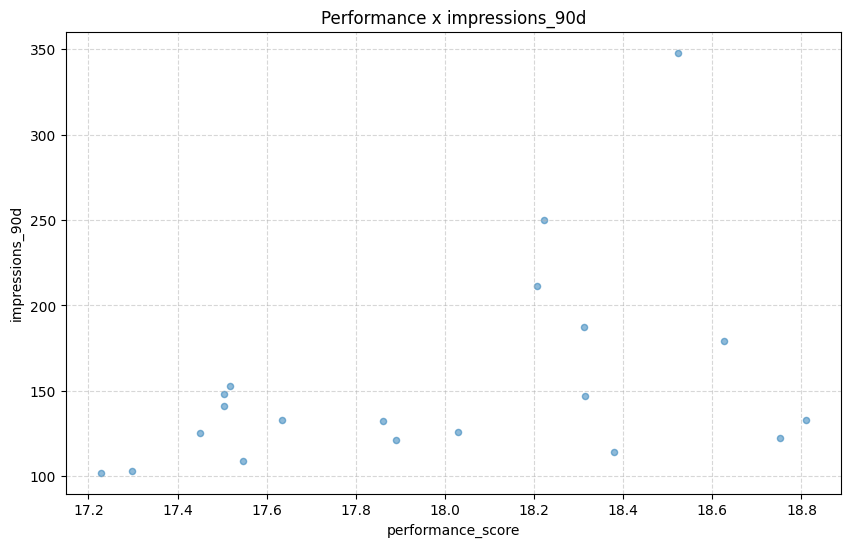

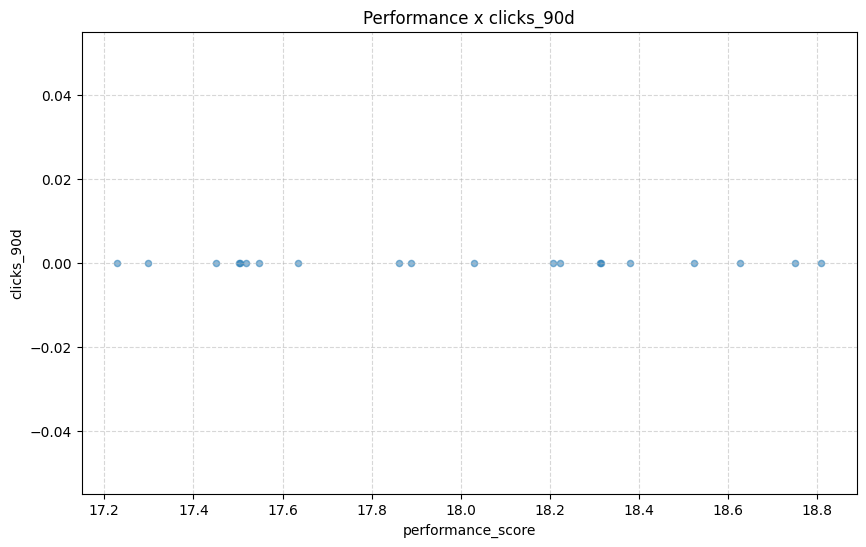

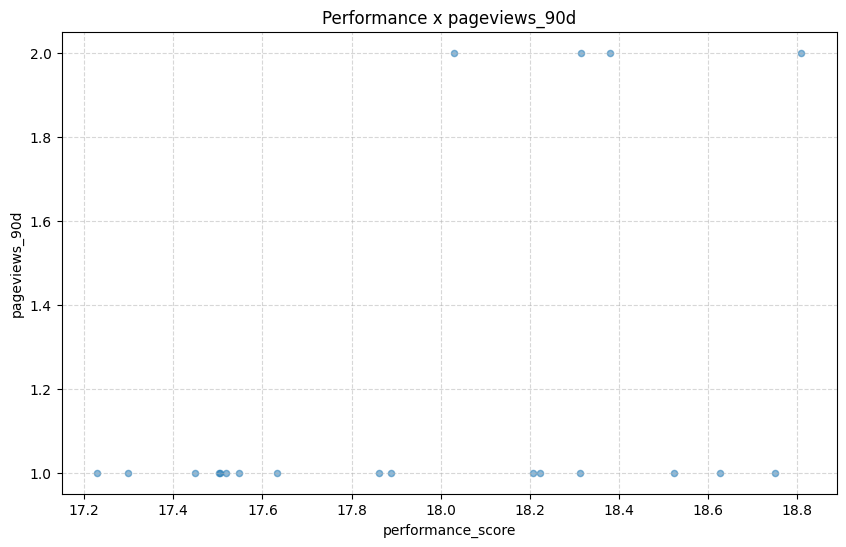

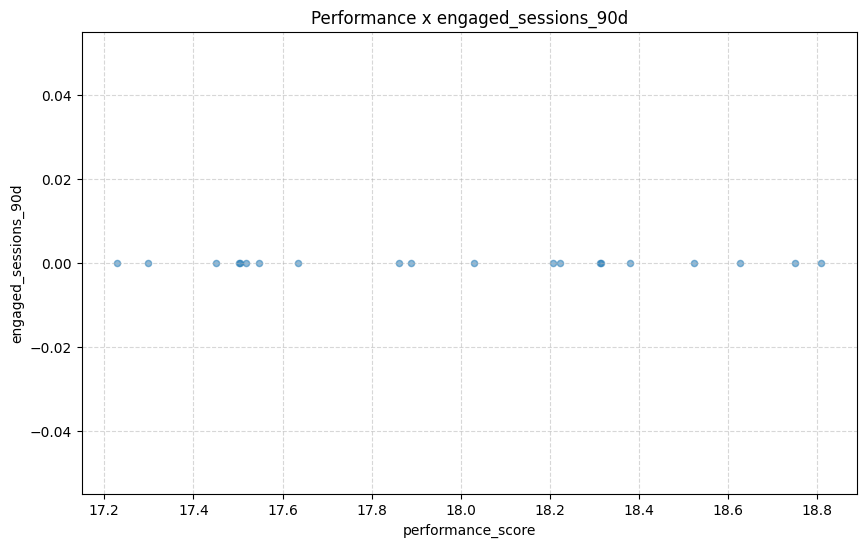

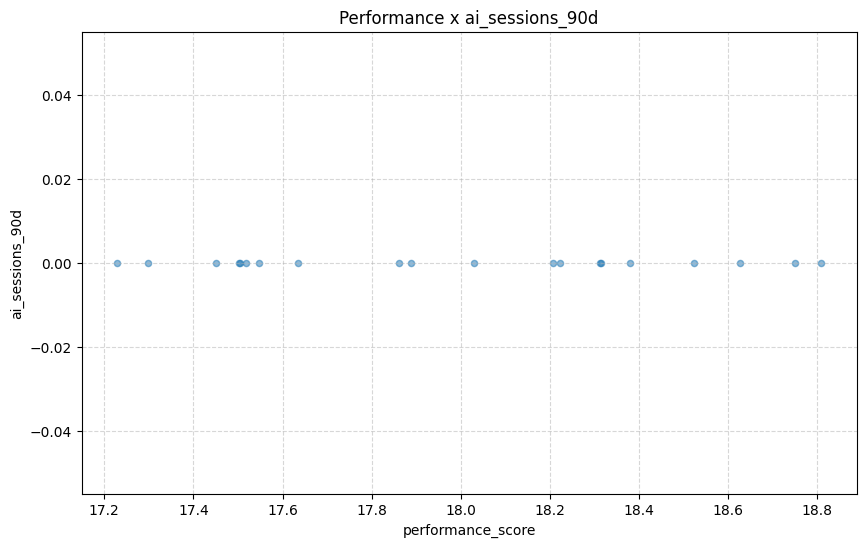

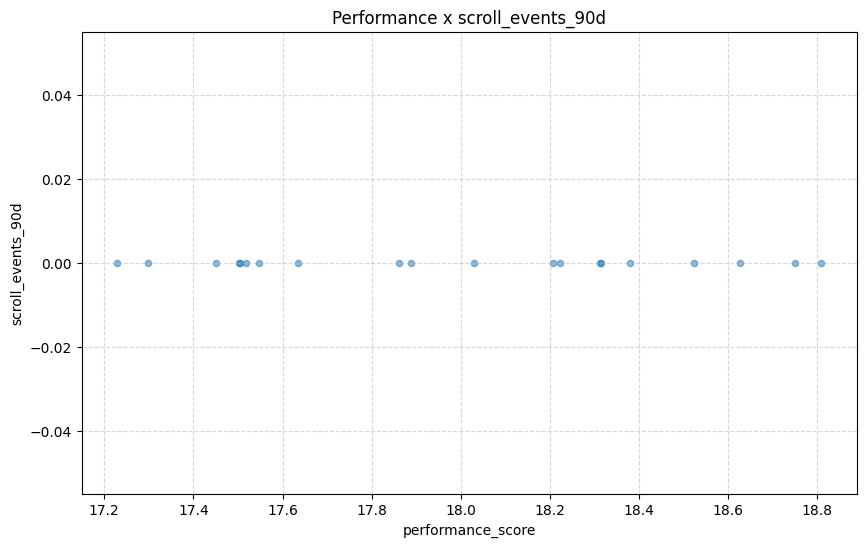

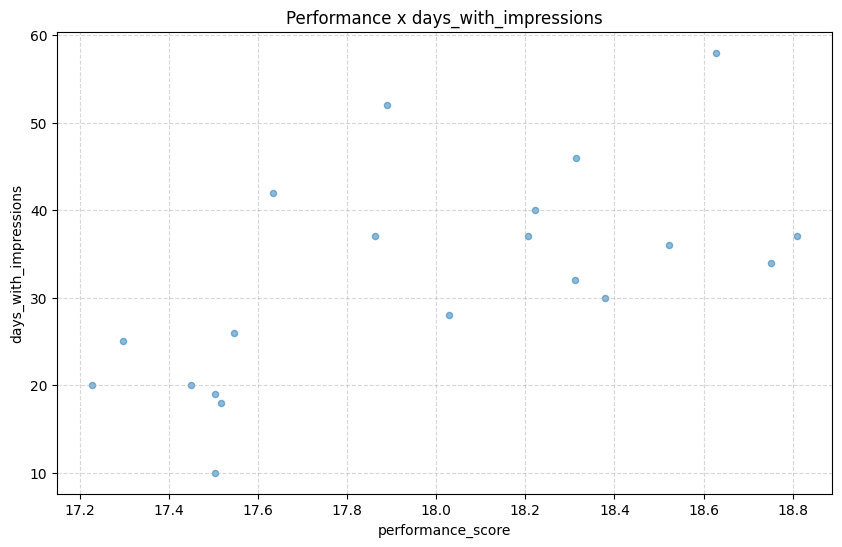

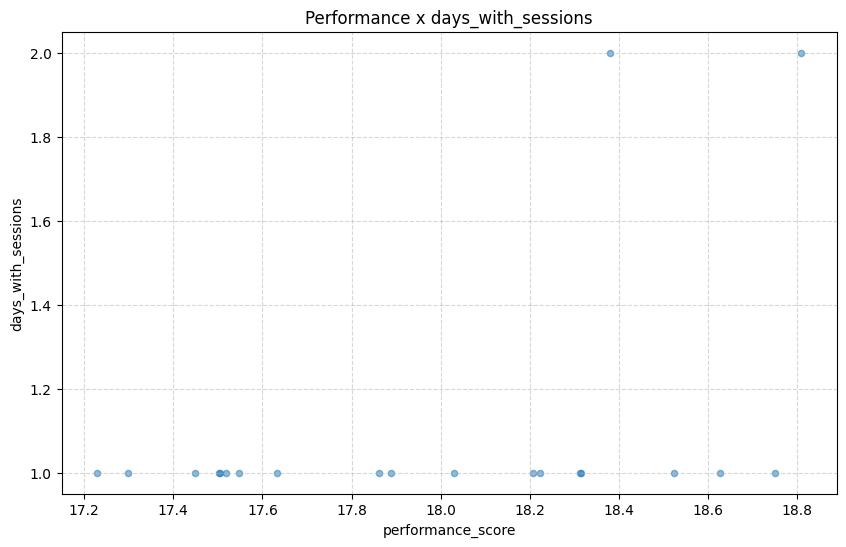

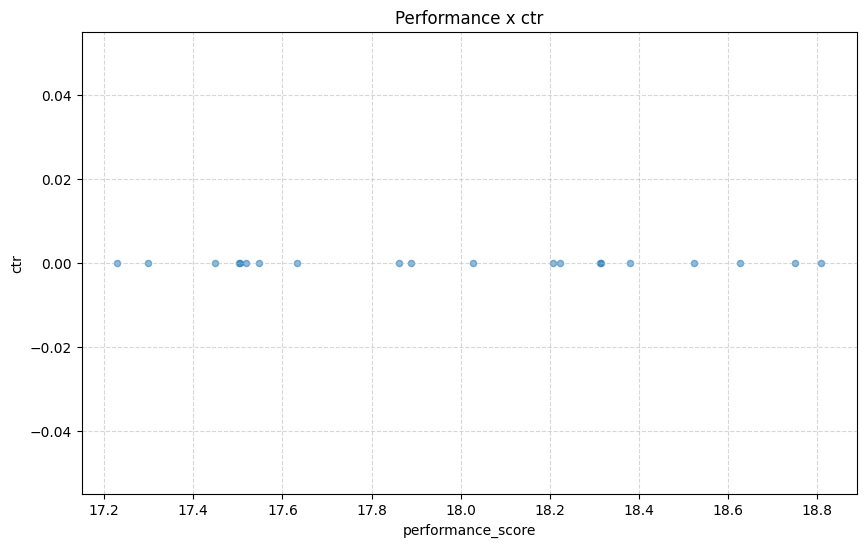

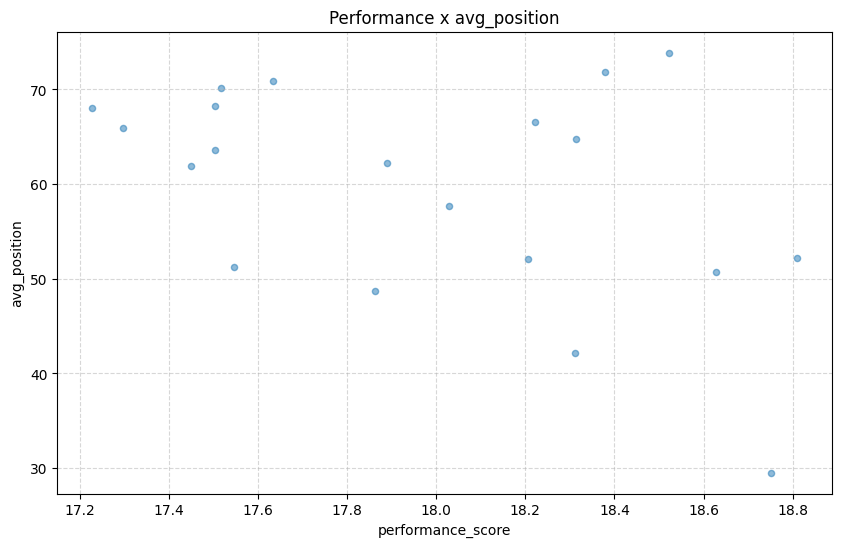

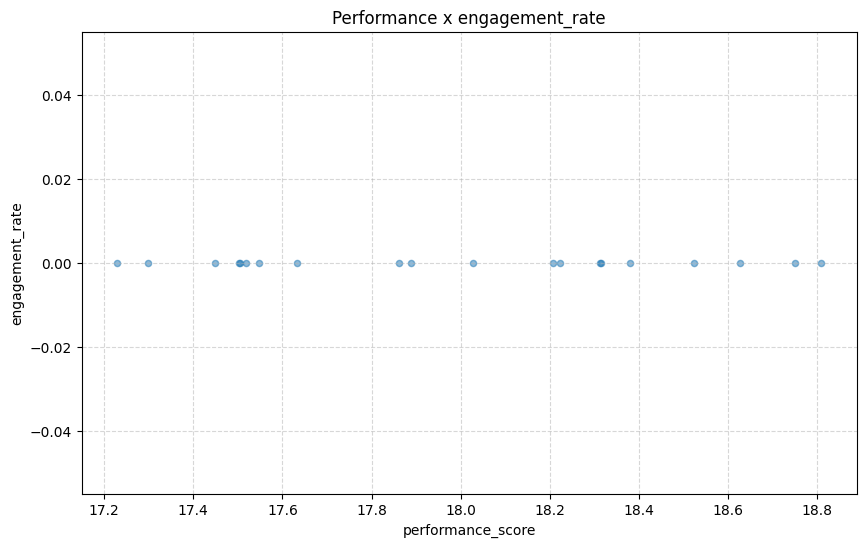

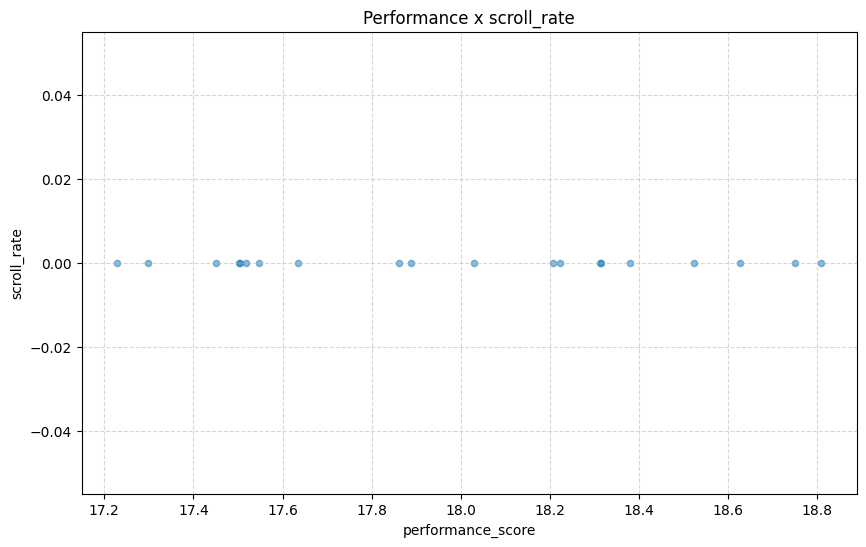

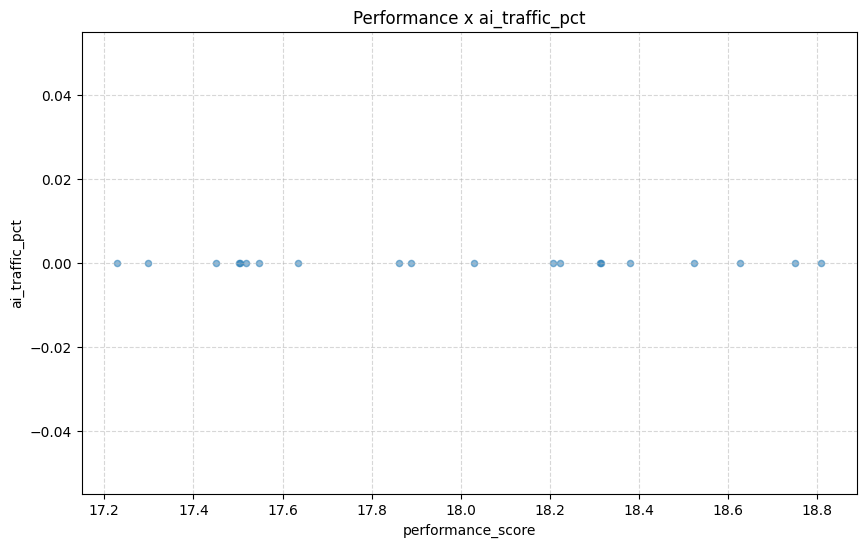

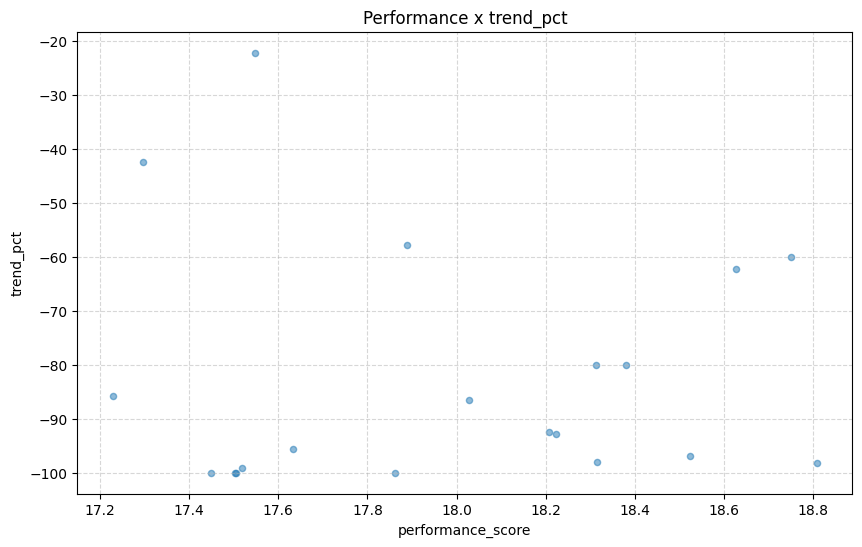

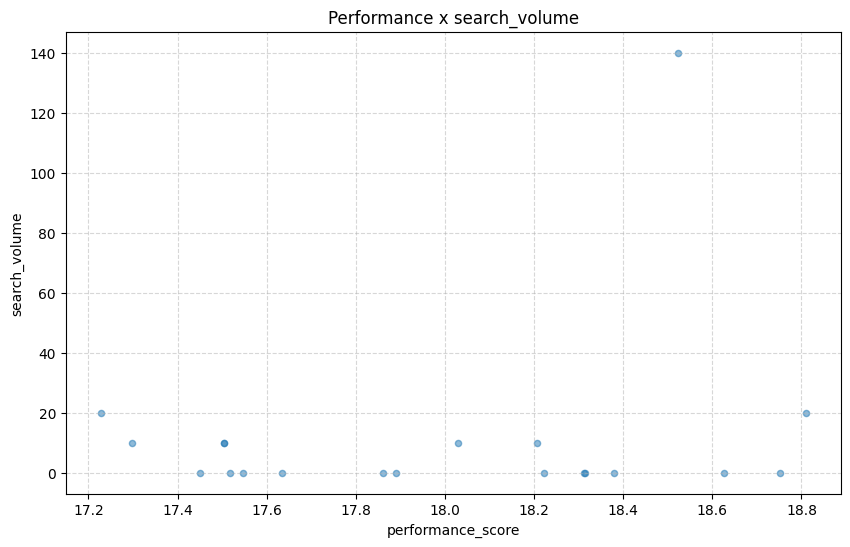

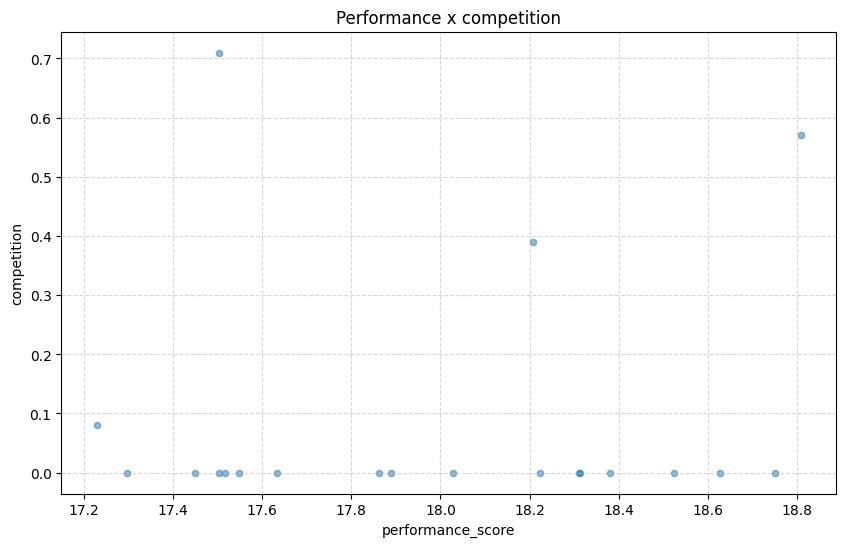

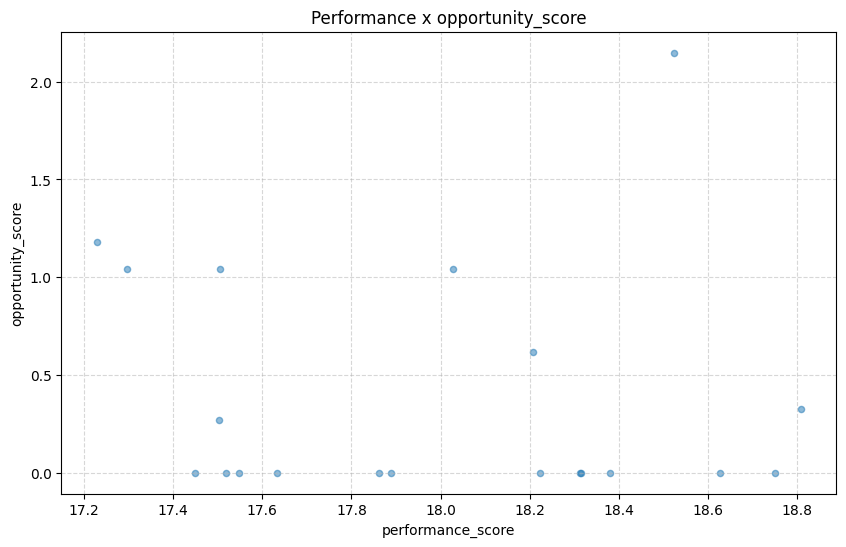

In [23]:
for i in num_cols:
  ax = down.plot(
    kind="scatter",
    x="performance_score",
    y=i,
    alpha=0.5,  # Makes overlapping points transparent so you can see density
    title= f"Performance x {i}",
    figsize=(10, 6),
)

  # Use log scale if high-volume outliers compress your chart
  plt.grid(True, linestyle="--", alpha=0.5)
  plt.show()
  print ('')
  print('')

In [24]:
content_data_columns

['content_id',
 'client_id',
 'cpc',
 'content_type',
 'main_intent',
 'word_count',
 'char_count',
 'provider_used',
 'model_used',
 'content_age_days',
 'days_since_last_update']

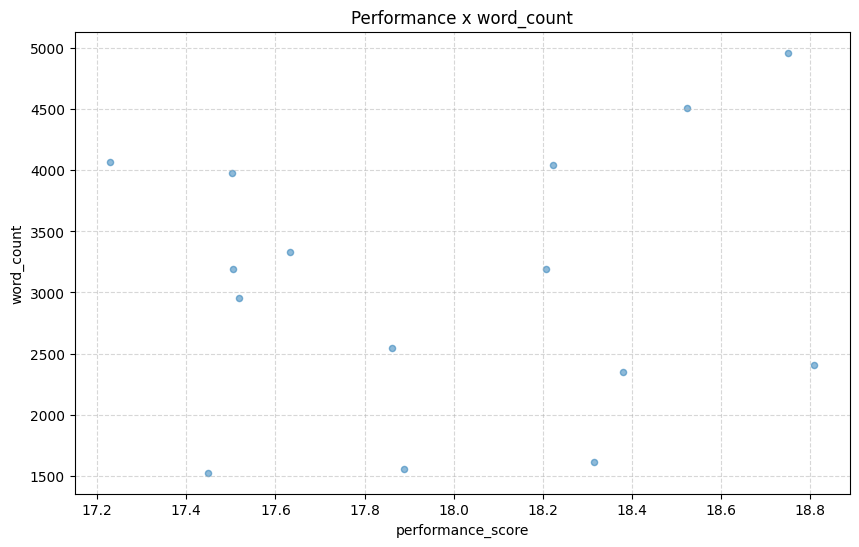

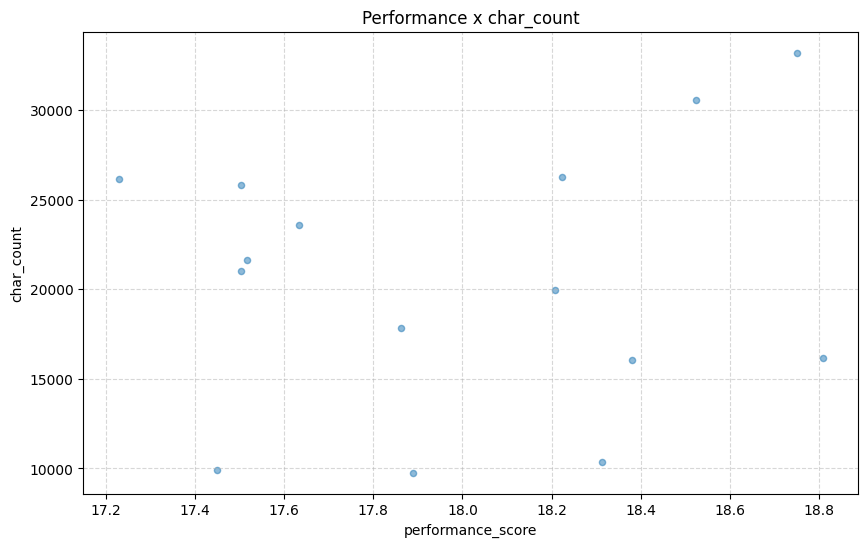

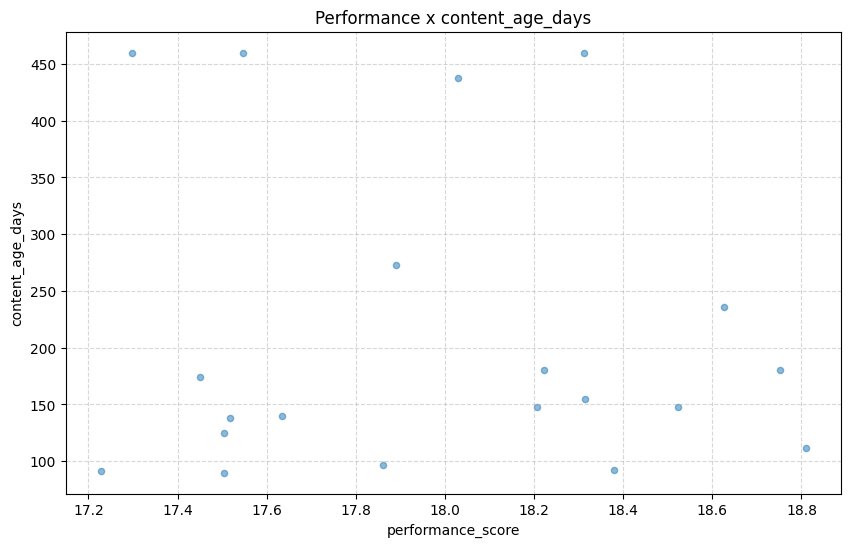

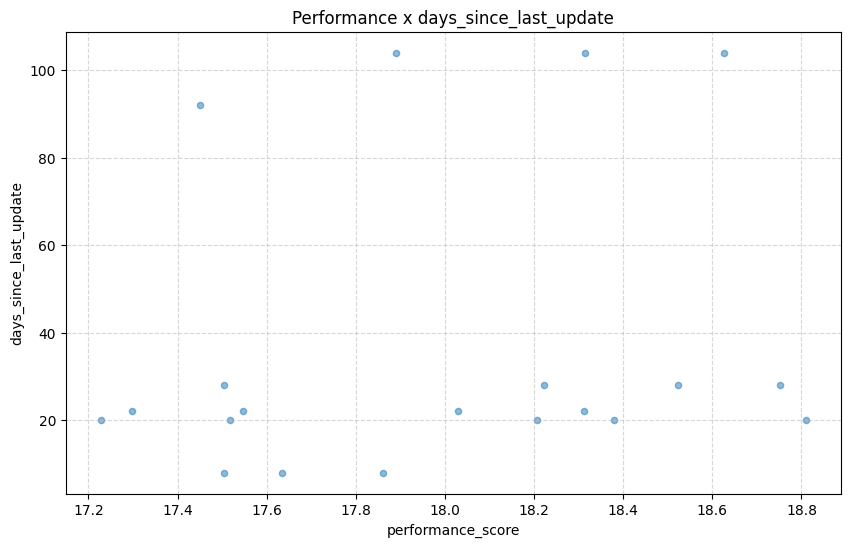

In [25]:
content_loop = ['word_count', 'char_count', 'content_age_days', 'days_since_last_update']
for i in content_loop:
  ax = down.plot(
    kind="scatter",
    x="performance_score",
    y=i,
    alpha=0.5,  # Makes overlapping points transparent so you can see density
    title= f"Performance x {i}",
    figsize=(10, 6),
)

  # Use log scale if high-volume outliers compress your chart
  plt.grid(True, linestyle="--", alpha=0.5)
  plt.show()
  print ('')
  print('')

Inference for the reference group

impression is around 100-350 which are all lower than the median of 731. There are no ctr or page sessions, position is around page 3 and 7 signalling an SEO problem. Although, most of the contents are fairly recent and uodated within the last month, the most striking part is that search_volume and competion are low showing that the content keywords may need to be reviewed or the topic are not relevant.

## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

What does not look right is that there are no ctr but 4 of the contents have page views and 2 with sessions. The only plausible explanation for this is that these contents were deliberately viewed through direct link, probably by creators and not from SERP/ SEO traffic.

Features were carefully selected when calculating the performance score, to ensure that the features are unique and correlated features do not add a dead weight in inflating the score. trend_pct was also excluded from claculating the performance score. Although it shows the performance of the content, `trend_direction' a feature engineered from trend_pct was used in selecting the review group, which would have otherwise introduced bias or leakage.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.